In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and Quick Quality Assessment of Data

In [ ]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [ ]:
# Display summary statistics for each column
for col in df.columns:
    print(f"{col} " + "=" * 50)
    if df[col].dtype == 'str':
        print(df[col].value_counts())
    elif df[col].dtype in ['int64', 'float64']:
        print(df[col].describe())
        print("Missing values:", df[col].isnull().sum())
    print()

age ==================================================
count    41188.00000
mean        40.02406
std         10.42125
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64
Missing values: 0

job ==================================================
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital ==================================================
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education ==================================================
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y         

In [ ]:
# missing values
missing_values = (df == 'unknown').sum()
percent_missing = ((missing_values / len(df)) * 100).round(2)
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percent Missing': percent_missing})
print(missing_df[missing_df['Missing Values'] > 0])

rows_with_missing = ((df == 'unknown') | df.isnull()).any(axis=1).sum()
percent_missing = (rows_with_missing / len(df)) * 100
print(f"\nNumber of rows with missing values: {rows_with_missing} ({percent_missing:.2f}%)")

           Missing Values  Percent Missing
job                   330             0.80
marital                80             0.19
education            1731             4.20
default              8597            20.87
housing               990             2.40
loan                  990             2.40

Number of rows with missing values: 10700 (25.98%)


In [ ]:
df['y'].value_counts() / len(df) * 100

y
no     88.734583
yes    11.265417
Name: count, dtype: float64

## Handling Missing Values

**SUMMARY**
- test for MCAR, MNAR
- multinomial logistic regression for nominal features
- KNN imputation for ordinal features

# Preprocessing

**Imputation Summary**
- treat `unknown` (string) as missing value
- treat missing values for `default` as a category
- test for MCAR, MNAR
- multinomial logistic regression for nominal features
- KNN imputation for ordinal features

**Transformation Summary**
- transform `y` to boolean
- drop `duration`, `pdays` column
- one-hot encode `job`, `marital`, `contact`, `month`, `poutcome` `housing`, `loan`, `default` and `day_of_week`
- ordinal encode `education`
- standardize all features
- multicollinearity check
  - drop `poutcome_nonexistent` due to high correlation with `previous`
  - perform PCA for macroeconomic indicators (`cons.price.idx`, `euribor3m`, `nr.employed`, `euribor3m`)
  - only keep the first principal component as it explains 85% of the variance

## Test for MCAR, MNAR

In [ ]:
from lib import *

In [ ]:
mcar_test_results = tp_test_mcar(df)

In [ ]:
missing_cols = ["job", "marital", "education", "default", "housing", "loan"]
significants = mcar_test_results[
    (mcar_test_results['missing_column'] != 'default')          # treat missing default as a separate category
    & (mcar_test_results['p_value'] < 0.05)                     # significant association with tested column
    & (~mcar_test_results['tested_column'].isin(missing_cols))  # exclude columns with missing values as tested columns
].sort_values('missing_column')
print(significants['missing_column'].unique())
significants
# From this, we can see that all missing columns are not MCAR

<StringArray>
['education', 'housing', 'job', 'loan', 'marital']
Length: 5, dtype: str


,missing_column,tested_column,p_value
29,education,y,1.629895e-05
89,education,nr.employed,1.048714e-03
88,education,euribor3m,4.915301e-03
87,education,cons.conf.idx,9.867530e-06
25,education,contact,3.416578e-05
26,education,month,6.544704e-19
27,education,day_of_week,8.552996e-04
28,education,poutcome,7.100547e-04
80,education,age,9.500015e-40
86,education,cons.price.idx,2.793088e-11


## Imputation

In [ ]:
from lib import *
from sklearn.model_selection import train_test_split

# split into train/test before imputation to avoid data leakage
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42, stratify=df['y'])

In [ ]:
# take ~4 mins
logreg_opts = {
    'solver': 'newton-cg',
    'max_iter': 1000,
}
multi_imputer = TPMultinomialImputer(logreg_opts=logreg_opts)
multi_imputer.fit(df_train)

In [ ]:
df_train_multi_imputed = multi_imputer.transform(df_train, verbose=True)


Imputation summary for 'job':
               Before  Percent Before   After  Imputed  Percent Imputed
job                                                                    
admin.           8314           25.23  8403.0     89.0             0.34
blue-collar      7441           22.58  7559.0    118.0             0.45
technician       5400           16.39  5416.0     16.0             0.06
services         3196            9.70  3196.0      0.0             0.00
management       2345            7.12  2345.0      0.0             0.00
retired          1366            4.15  1403.0     37.0             0.14
entrepreneur     1160            3.52  1160.0      0.0             0.00
self-employed    1099            3.34  1099.0      0.0             0.00
housemaid         855            2.59   855.0      0.0             0.00
unemployed        798            2.42   798.0      0.0             0.00
student           711            2.16   716.0      5.0             0.02
unknown           265            

In [ ]:
df_test_multi_imputed = multi_imputer.transform(df_test, verbose=True)


Imputation summary for 'job':
               Before  Percent Before   After  Imputed  Percent Imputed
job                                                                    
admin.           2108           25.59  2133.0     25.0             0.38
blue-collar      1813           22.01  1847.0     34.0             0.52
technician       1343           16.30  1345.0      2.0             0.03
services          773            9.38   773.0      0.0             0.00
management        579            7.03   579.0      0.0             0.00
retired           354            4.30   358.0      4.0             0.06
self-employed     322            3.91   322.0      0.0             0.00
entrepreneur      296            3.59   296.0      0.0             0.00
unemployed        216            2.62   216.0      0.0             0.00
housemaid         205            2.49   205.0      0.0             0.00
student           164            1.99   164.0      0.0             0.00
unknown            65            

In [ ]:
knn_imputer = TPKNNImputer()
knn_imputer.fit(df_train_multi_imputed)

In [ ]:
df_train_knn_imputed = knn_imputer.transform(df_train_multi_imputed, verbose=True)


Imputation summary for 'education':
                     Before  Percent Before   After  Imputed  Percent Imputed
education                                                                    
university.degree      9736           29.55  9792.0     56.0             0.04
high.school            7596           23.05  8153.0    557.0             0.40
basic.9y               4826           14.65  5171.0    345.0             0.25
professional.course    4192           12.72  4560.0    368.0             0.26
basic.4y               3322           10.08  3324.0      2.0             0.00
basic.6y               1865            5.66  1934.0     69.0             0.05
unknown                1397            4.24     NaN      NaN              NaN
illiterate               16            0.05    16.0      0.0             0.00


In [ ]:
df_test_knn_imputed = knn_imputer.transform(df_test_multi_imputed, verbose=True)


Imputation summary for 'education':
                     Before  Percent Before   After  Imputed  Percent Imputed
education                                                                    
university.degree      2432           29.52  2445.0     13.0             0.04
high.school            1919           23.29  2053.0    134.0             0.40
basic.9y               1219           14.80  1305.0     86.0             0.26
professional.course    1051           12.76  1134.0     83.0             0.25
basic.4y                854           10.37   857.0      3.0             0.01
basic.6y                427            5.18   442.0     15.0             0.04
unknown                 334            4.05     NaN      NaN              NaN
illiterate                2            0.02     2.0      0.0             0.00


## Transformations

In [ ]:
df_train_transformed = tp_simple_transform(df_train_knn_imputed)
df_test_transformed = tp_simple_transform(df_test_knn_imputed)

In [ ]:
df_train_encoded = tp_encode(df_train_transformed)
df_test_encoded = tp_encode(df_test_transformed)
df_test_encoded['default_yes'] = False

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df_train_encoded.select_dtypes(exclude=["bool", "boolean"]).columns.tolist()
scaler = StandardScaler()
scaler.fit(df_train_encoded[numeric_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [ ]:
df_train_numeric_scaled = pd.DataFrame(
    scaler.transform(df_train_encoded[numeric_cols]),
    columns = numeric_cols
)
df_test_numeric_scaled = pd.DataFrame(
    scaler.transform(df_test_encoded[numeric_cols]),
    columns = numeric_cols
)
df_train_numeric_scaled.head()

,age,education,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,0.863739,-0.714094,0.522981,-0.350127,-0.114858,-0.648967,-0.322269,0.288964,0.398990
1,-0.289722,1.142561,-0.203688,1.653813,-0.114858,-0.648967,-0.322269,0.288964,0.398990
2,3.651268,-1.951863,-0.567023,-0.350127,-1.133161,1.103451,0.045048,-1.583296,-2.420139
3,-0.385843,1.142561,-0.203688,-0.350127,0.648868,0.721890,0.887717,0.713535,0.332723
4,1.824956,1.142561,-0.203688,-0.350127,-1.896888,-1.058152,-0.062987,-1.357472,-1.252175


In [ ]:
df_train_scaled = df_train_encoded.copy().reset_index(drop=True)
df_test_scaled = df_test_encoded.copy().reset_index(drop=True)
for col in numeric_cols:
    df_train_scaled[col] = df_train_numeric_scaled[col]
    df_test_scaled[col] = df_test_numeric_scaled[col]

## Handle Multicollinearity

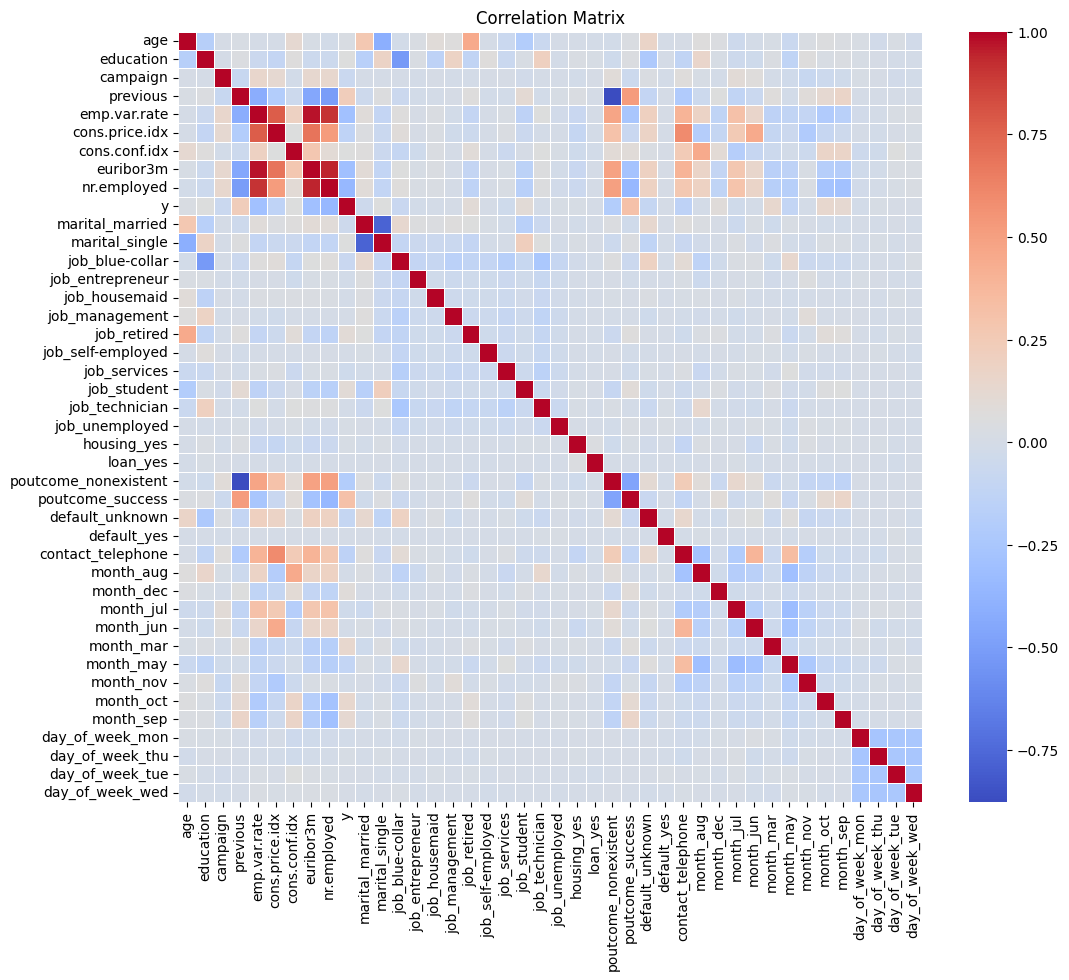

In [ ]:
# multicollinearity check
correlation_matrix = df_train_scaled.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [ ]:
"""
From this we can see that 
- 4 macroeconomic indicators are highly correlated with each other. ('cons.price.idx', 'euribor3m', 'nr.employed', 'euribor3m')
- 'marital_single' and 'marital_married' are highly correlated. Will leave as is.
- 'poutcome_nonexistent' and 'previous' are highly correlated. Will drop 'poutcome_nonexistent'.
"""

# check for high correlation (> 0.7)
high_correlations = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) > 0.7: # type: ignore
            high_correlations.append((
                correlation_matrix.columns[i], 
                correlation_matrix.columns[j], 
                correlation_matrix.iloc[i, j])
            )

df_high_corr = pd.DataFrame(high_correlations, columns=['col1', 'col2', 'correlation'])
df_high_corr

,col1,col2,correlation
0,cons.price.idx,emp.var.rate,0.773923
1,euribor3m,emp.var.rate,0.972154
2,nr.employed,emp.var.rate,0.906313
3,nr.employed,euribor3m,0.944974
4,marital_single,marital_married,-0.777825
5,poutcome_nonexistent,previous,-0.876529


In [ ]:
df_train_scaled.drop(columns=['poutcome_nonexistent'], inplace=True)
df_test_scaled.drop(columns=['poutcome_nonexistent'], inplace=True)

In [ ]:
from sklearn.decomposition import PCA
PCA_cols = ['emp.var.rate', 'cons.price.idx', 'euribor3m', 'nr.employed']

# PCA on selected columns only
pca = PCA(n_components=len(PCA_cols))
pca.fit(df_train_scaled[PCA_cols])
train_pca_values = pca.transform(df_train_scaled[PCA_cols])
test_pca_values = pca.transform(df_test_scaled[PCA_cols])

# Build PCA feature frame
pca_feature_names = [f"macro_eco{i+1}" for i in range(train_pca_values.shape[1])]
df_train_pca_features = pd.DataFrame(
    train_pca_values,
    columns=pca_feature_names,
    index=df_train_scaled.index
)
df_test_pca_features = pd.DataFrame(
    test_pca_values,
    columns=pca_feature_names,
    index=df_test_scaled.index
)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.cumsum())

# Keep original df_train_scaled unchanged; create new dataset with PCA features
df_train_pca = pd.concat(
    [df_train_scaled.drop(columns=PCA_cols), df_train_pca_features['macro_eco1']],  # only keep first PC which explains >80% variance
    axis=1
)
df_test_pca = pd.concat(
    [df_test_scaled.drop(columns=PCA_cols), df_test_pca_features['macro_eco1']],
    axis=1
)
df_train_pca.head()

Explained variance ratio: [0.85596501 0.13021275 0.00912533 0.00469691]
Cumulative explained variance: [0.85596501 0.98617776 0.99530309 1.        ]


,age,education,campaign,previous,cons.conf.idx,y,marital_married,marital_single,job_blue-collar,job_entrepreneur,...,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,macro_eco1
0,0.863739,-0.714094,0.522981,-0.350127,-0.322269,False,True,False,True,False,...,False,False,True,False,False,False,False,False,True,0.013012
1,-0.289722,1.142561,-0.203688,1.653813,-0.322269,False,True,False,False,True,...,False,False,True,False,False,False,False,False,True,0.013012
2,3.651268,-1.951863,-0.567023,-0.350127,0.045048,True,True,False,False,False,...,False,False,False,False,False,True,False,False,False,-2.181465
3,-0.385843,1.142561,-0.203688,-0.350127,0.887717,False,True,False,False,False,...,False,True,False,False,False,True,False,False,False,1.200832
4,1.824956,1.142561,-0.203688,-0.350127,-0.062987,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,-2.813321


# Output

## Export Processed Datasets

In [26]:
df_train_pca.to_csv('processed-data/train.csv', index=False)
df_test_pca.to_csv('processed-data/test.csv', index=False)

## Export Preprocessors

In [27]:
"""
PREPROCESSORS TO EXPORT:
- multi_imputer: TPMultinomialImputer
- knn_imputer: TPKNNImputer
- scaler: StandardScaler
- pca: PCA (with metadata: )

METADATA TO EXPORT:
- numeric_cols; for reference when applying scaling transformation to new data in production
- PCA_cols; for reference when applying PCA transformation to new data in production
- drop_cols_after_encode: ['poutcome_nonexistent']; for reference when applying same column dropping to new data in production
- final_feature_order: for rensuring same column order as training data
"""

"\nPREPROCESSORS TO EXPORT:\n- multi_imputer: TPMultinomialImputer\n- knn_imputer: TPKNNImputer\n- scaler: StandardScaler\n- pca: PCA (with metadata: )\n\nMETADATA TO EXPORT:\n- numeric_cols; for reference when applying scaling transformation to new data in production\n- PCA_cols; for reference when applying PCA transformation to new data in production\n- drop_cols_after_encode: ['poutcome_nonexistent']; for reference when applying same column dropping to new data in production\n- final_feature_order: for rensuring same column order as training data\n"

In [28]:
import json
import joblib

preproc_path = "preprocessor/preprocessors.joblib"
meta_path = "preprocessor/preprocessors_meta.json"

bundle = {
    "multi_imputer": multi_imputer,   # TPMultinomialImputer
    "knn_imputer": knn_imputer,       # TPKNNImputer
    "scaler": scaler,                 # StandardScaler
    "pca": pca                        # PCA
}
joblib.dump(bundle, preproc_path)

meta = {
    "PCA_cols": PCA_cols,
    "numeric_cols": numeric_cols,
    "drop_cols_after_encode": ["poutcome_nonexistent"],
    "final_feature_order": df_train_pca.columns.tolist()
}
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)